## Loading data

In [48]:
import pandas as pd

file_path = "../data/training/RMBR4-2_export_test.csv"

df = pd.read_csv(file_path)

df.head()

,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #9,Axis #10,Axis #11,Axis #12,Axis #13,Axis #14,Time
0,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:23.660Z
1,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:25.472Z
2,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:27.348Z
3,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:29.222Z
4,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:31.117Z


## Cleaning data

In [49]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Trait           0
Axis #1         0
Axis #2         0
Axis #3         0
Axis #4         0
Axis #5         0
Axis #6         0
Axis #7         0
Axis #8         0
Axis #9     39672
Axis #10    39672
Axis #11    39672
Axis #12    39672
Axis #13    39672
Axis #14    39672
Time            0
dtype: int64


In [50]:
df.describe()

,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #9,Axis #10,Axis #11,Axis #12,Axis #13,Axis #14
count,39672.000000,39672.000000,39672.000000,39672.000000,39672.000000,39672.000000,39672.000000,39672.000000,0.0,0.0,0.0,0.0,0.0,0.0
mean,0.725743,3.613374,2.710336,0.620222,0.954521,0.599427,0.870145,0.102214,NaN,NaN,NaN,NaN,NaN,NaN
std,2.162120,6.879962,5.111901,1.574897,2.100186,1.815498,2.166811,0.423075,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,0.312710,4.217190,4.586190,0.516190,0.800090,0.361330,0.310030,0.078480,NaN,NaN,NaN,NaN,NaN,NaN
max,23.609300,51.713230,41.855560,15.666300,20.750760,20.931420,8.108480,5.905640,NaN,NaN,NaN,NaN,NaN,NaN


Columns Axis #9 through Axis #14 are not required and contain only missing values, so they are excluded from the analysis.

In [51]:
selected_columns = [
    "Trait",
    "Axis #1",
    "Axis #2",
    "Axis #3",
    "Axis #4",
    "Axis #5",
    "Axis #6",
    "Axis #7",
    "Axis #8",
    "Time"
]

df_selected = df[selected_columns].copy()

df_selected.head()

,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Time
0,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-17T12:18:23.660Z
1,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-17T12:18:25.472Z
2,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-17T12:18:27.348Z
3,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-17T12:18:29.222Z
4,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-17T12:18:31.117Z


### Time Variable Analysis

Before training the models, the Time column should be converted into a numerical representation.

In [52]:
print(df_selected["Time"].head(10))
print("\nLast values:")
print(df_selected["Time"].tail(10))

0    2022-10-17T12:18:23.660Z
1    2022-10-17T12:18:25.472Z
2    2022-10-17T12:18:27.348Z
3    2022-10-17T12:18:29.222Z
4    2022-10-17T12:18:31.117Z
5    2022-10-17T12:18:32.964Z
6    2022-10-17T12:18:34.894Z
7    2022-10-17T12:18:36.782Z
8    2022-10-17T12:18:38.708Z
9    2022-10-17T12:18:40.529Z
Name: Time, dtype: str

Last values:
39662    2022-10-18T10:44:41.620Z
39663    2022-10-18T10:44:43.487Z
39664    2022-10-18T10:44:45.409Z
39665    2022-10-18T10:44:47.238Z
39666    2022-10-18T10:44:49.176Z
39667    2022-10-18T10:44:51.049Z
39668    2022-10-18T10:44:52.988Z
39669    2022-10-18T10:44:54.838Z
39670    2022-10-18T10:44:56.706Z
39671    2022-10-18T10:44:58.628Z
Name: Time, dtype: str


The original Time column contains timestamps. For Linear Regression, time is converted into elapsed seconds starting from the first observation.

In [53]:
# Convert Time from string to datetime
df_selected["Time_datetime"] = pd.to_datetime(df_selected["Time"])

# Calculate elapsed time in seconds from the first measurement
df_selected["Time_seconds"] = (
    df_selected["Time_datetime"] - df_selected["Time_datetime"].iloc[0]
).dt.total_seconds()

df_selected[["Time", "Time_datetime", "Time_seconds"]].head(10)

,Time,Time_datetime,Time_seconds
0,2022-10-17T12:18:23.660Z,2022-10-17 12:18:23.660000+00:00,0.000
1,2022-10-17T12:18:25.472Z,2022-10-17 12:18:25.472000+00:00,1.812
2,2022-10-17T12:18:27.348Z,2022-10-17 12:18:27.348000+00:00,3.688
3,2022-10-17T12:18:29.222Z,2022-10-17 12:18:29.222000+00:00,5.562
4,2022-10-17T12:18:31.117Z,2022-10-17 12:18:31.117000+00:00,7.457
5,2022-10-17T12:18:32.964Z,2022-10-17 12:18:32.964000+00:00,9.304
6,2022-10-17T12:18:34.894Z,2022-10-17 12:18:34.894000+00:00,11.234
7,2022-10-17T12:18:36.782Z,2022-10-17 12:18:36.782000+00:00,13.122
8,2022-10-17T12:18:38.708Z,2022-10-17 12:18:38.708000+00:00,15.048
9,2022-10-17T12:18:40.529Z,2022-10-17 12:18:40.529000+00:00,16.869


### Current Data Visualization

The current measurements for Axis #1 through Axis #8 are plotted over elapsed time.

This visualization helps identify patterns, variations, peaks, and possible anomalies in the training data before fitting the Linear Regression models.

In [54]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

axes = [f"Axis #{i}" for i in range(1, 9)]

# Start with Axis #1
current_index = 0

# Create buttons
previous_button = widgets.Button(description="← Previous")
next_button = widgets.Button(description="Next →")

# Area where the graph will be displayed
output = widgets.Output()


def show_graph(index):
    with output:
        clear_output(wait=True)

        axis = axes[index]

        plt.figure(figsize=(12, 4))

        plt.plot(
            df_selected["Time_seconds"],
            df_selected[axis]
        )

        plt.title(f"{axis} Current Over Time")
        plt.xlabel("Elapsed Time (seconds)")
        plt.ylabel("Current")
        plt.grid(True)
        plt.show()


def previous_graph(b):
    global current_index

    if current_index > 0:
        current_index -= 1

    show_graph(current_index)


def next_graph(b):
    global current_index

    if current_index < len(axes) - 1:
        current_index += 1

    show_graph(current_index)


# Connect buttons to functions
previous_button.on_click(previous_graph)
next_button.on_click(next_graph)

# Display buttons and graph
display(widgets.HBox([previous_button, next_button]))
display(output)

# Show first graph
show_graph(current_index)

Output()

Linear Regression - Axis #1

A univariate Linear Regression model is trained using elapsed time as the independent variable (X) and Axis #1 current as the dependent variable (y).

The model learns the general relationship between time and the current measurements.

In [ ]:
from sklearn.linear_model import LinearRegression

X = df_selected[["Time_seconds"]] 
y = df_selected["Axis #1"]

# Create a Linear Regression model
model_axis1 = LinearRegression()
model_axis1.fit(X, y) #Learn the relationship between Time and Axis #1 using training data.

df_selected["Axis #1_predicted"] = model_axis1.predict(X)
df_selected[
    ["Time_seconds", "Axis #1", "Axis #1_predicted"]
].head(10)

,Time_seconds,Axis #1,Axis #1_predicted
0,0.000,0.0,0.730542
1,1.812,0.0,0.730542
2,3.688,0.0,0.730542
3,5.562,0.0,0.730541
4,7.457,0.0,0.730541
5,9.304,0.0,0.730541
6,11.234,0.0,0.730541
7,13.122,0.0,0.730541
8,15.048,0.0,0.730540
9,16.869,0.0,0.730540


In [56]:
df_selected["Axis #1_residual"] = (
    df_selected["Axis #1"]
    - df_selected["Axis #1_predicted"]
)

df_selected[
    [
        "Time_seconds",
        "Axis #1",
        "Axis #1_predicted",
        "Axis #1_residual"
    ]
].head(40)

##Actual - Predicted = Residual

,Time_seconds,Axis #1,Axis #1_predicted,Axis #1_residual
0,0.000,0.00000,0.730542,-0.730542
1,1.812,0.00000,0.730542,-0.730542
2,3.688,0.00000,0.730542,-0.730542
3,5.562,0.00000,0.730541,-0.730541
4,7.457,0.00000,0.730541,-0.730541
5,9.304,0.00000,0.730541,-0.730541
6,11.234,0.00000,0.730541,-0.730541
7,13.122,0.00000,0.730541,-0.730541
8,15.048,0.00000,0.730540,-0.730540
9,16.869,0.00000,0.730540,-0.730540


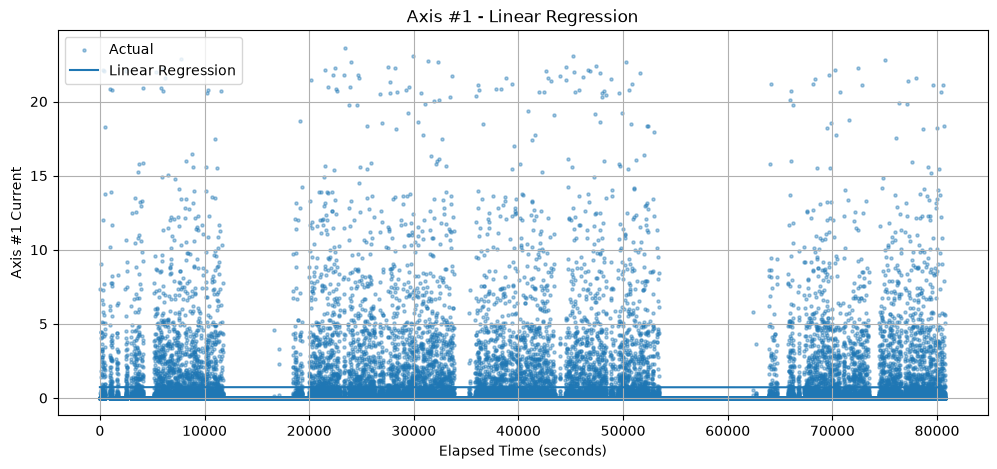

In [57]:
plt.figure(figsize=(12, 5))

plt.scatter(
    df_selected["Time_seconds"],
    df_selected["Axis #1"],
    s=5,
    alpha=0.4,
    label="Actual"
)

plt.plot(
    df_selected["Time_seconds"],
    df_selected["Axis #1_predicted"],
    label="Linear Regression"
)

plt.xlabel("Elapsed Time (seconds)")
plt.ylabel("Axis #1 Current")
plt.title("Axis #1 - Linear Regression")
plt.legend()
plt.grid(True)

plt.show()

## Linear Regression Models for Axis #1–#8

Elapsed time is used as the independent variable (X), while each axis current measurement is used as the dependent variable (y).

For each model, the slope, intercept, predictions, and residuals are calculated for further anomaly analysis.

In [62]:
from sklearn.linear_model import LinearRegression

axes = [f"Axis #{i}" for i in range(1, 9)]

models = {}
model_results = []

X = df_selected[["Time_seconds"]]

for axis in axes:

    # Actual current values
    y = df_selected[axis]

    # Create and train model
    model = LinearRegression()
    model.fit(X, y)

    # Store trained model
    models[axis] = model

    # Predict the expected current values
    predicted = model.predict(X)

    # Store predictions and residuals
    df_selected[f"{axis}_predicted"] = predicted
    df_selected[f"{axis}_residual"] = (
        df_selected[axis] - predicted
    )

    # Store model information
    model_results.append({
        "Axis": axis,
        "Slope": model.coef_[0],
        "Intercept": model.intercept_
    })

df_selected.columns.tolist()

['Trait',
 'Axis #1',
 'Axis #2',
 'Axis #3',
 'Axis #4',
 'Axis #5',
 'Axis #6',
 'Axis #7',
 'Axis #8',
 'Time',
 'Time_datetime',
 'Time_seconds',
 'Axis #1_predicted',
 'Axis #1_residual',
 'Axis #2_predicted',
 'Axis #2_residual',
 'Axis #3_predicted',
 'Axis #3_residual',
 'Axis #4_predicted',
 'Axis #4_residual',
 'Axis #5_predicted',
 'Axis #5_residual',
 'Axis #6_predicted',
 'Axis #6_residual',
 'Axis #7_predicted',
 'Axis #7_residual',
 'Axis #8_predicted',
 'Axis #8_residual']

## Residual Analysis

Residuals represent the difference between the actual current measurement and the value predicted by the Linear Regression model.

**Residual = Actual - Predicted**

Positive residuals indicate that the observed current is above the expected value.


In [64]:
# Create a list with the residual column names for Axis #1 to Axis #8
residual_columns = [
    f"Axis #{i}_residual" for i in range(1, 9)
]

# Generate descriptive statistics for all residuals
residual_stats = df_selected[residual_columns].describe()
residual_stats

,Axis #1_residual,Axis #2_residual,Axis #3_residual,Axis #4_residual,Axis #5_residual,Axis #6_residual,Axis #7_residual,Axis #8_residual
count,3.967200e+04,3.967200e+04,3.967200e+04,3.967200e+04,3.967200e+04,3.967200e+04,3.967200e+04,39672.000000
mean,-5.731339e-17,2.980296e-16,3.668057e-16,6.304473e-17,-8.023874e-17,-1.203581e-16,-1.719402e-16,0.000000
std,2.162118e+00,6.879775e+00,5.111883e+00,1.574871e+00,2.100185e+00,1.815465e+00,2.166773e+00,0.423071
min,-7.305421e-01,-3.701166e+00,-2.733898e+00,-6.357863e-01,-9.578743e-01,-6.184102e-01,-8.923003e-01,-0.105615
25%,-7.268099e-01,-3.641124e+00,-2.715424e+00,-6.251986e-01,-9.555857e-01,-6.055158e-01,-8.772588e-01,-0.103300
50%,-7.233406e-01,-3.562495e+00,-2.698463e+00,-6.113027e-01,-9.525797e-01,-5.886695e-01,-8.576400e-01,-0.100259
75%,-4.153363e-01,6.319637e-01,1.873483e+00,-1.007698e-01,-1.517029e-01,-2.289985e-01,-5.543284e-01,-0.022984
max,2.288151e+01,4.808266e+01,3.916099e+01,1.505418e+01,1.979645e+01,2.032099e+01,7.260771e+00,5.802731


In [67]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# List of axes that can be explored
axes = [f"Axis #{i}" for i in range(1, 9)]

# Keep track of the currently displayed Axis
current_axis_index = 0

# Output area where the graph will be displayed
output = widgets.Output()


def plot_residual(axis):
    """
    Display the residuals for one Axis.

    Residual = Actual Current - Predicted Current

    Positive residual:
        Actual current is ABOVE the regression prediction.

    Negative residual:
        Actual current is BELOW the regression prediction.
    """

    # Name of the residual column we created previously
    residual_column = f"{axis}_residual"

    with output:

        # Remove the previous graph before showing the new one
        clear_output(wait=True)

        # Create the graph
        plt.figure(figsize=(12, 5))

        # Plot residuals against elapsed time
        plt.scatter(
            df_selected["Time_seconds"],
            df_selected[residual_column],
            s=5,
            alpha=0.5
        )

        # Add a horizontal reference line at residual = 0
        # Values above this line are above the regression prediction
        plt.axhline(
            y=0,
            linestyle="--",
            label="Expected level (Residual = 0)"
        )

        # Graph labels
        plt.title(f"{axis} - Residuals Over Time")
        plt.xlabel("Elapsed Time (seconds)")
        plt.ylabel("Residual (Actual - Predicted)")

        plt.legend()
        plt.grid(True)
        plt.show()


# Create navigation buttons
previous_button = widgets.Button(
    description="← Previous"
)

next_button = widgets.Button(
    description="Next →"
)

# Label showing which Axis is currently displayed
axis_label = widgets.Label()


def update_plot():
    """
    Refresh the graph using the currently selected Axis.
    """

    # Get Axis name using its position in the list
    axis = axes[current_axis_index]

    # Update label
    axis_label.value = f"Showing: {axis}"

    # Display corresponding residual graph
    plot_residual(axis)


def show_previous(button):
    """
    Move to the previous Axis.
    """

    global current_axis_index

    # Prevent going below Axis #1
    if current_axis_index > 0:
        current_axis_index -= 1

    update_plot()


def show_next(button):
    """
    Move to the next Axis.
    """

    global current_axis_index

    # Prevent going beyond Axis #8
    if current_axis_index < len(axes) - 1:
        current_axis_index += 1

    update_plot()


# Connect each button with its corresponding function
previous_button.on_click(show_previous)
next_button.on_click(show_next)

# Put both buttons on the same horizontal row
navigation = widgets.HBox([
    previous_button,
    next_button,
    axis_label
])

# Display controls and graph area
display(navigation)
display(output)

# Show Axis #1 when the cell runs
update_plot()

Output()

### Positive Residual Analysis and Threshold Discovery

Since Alert and Error events are defined as current values above the regression prediction, the analysis focuses on positive residuals.

Percentiles are used to understand the distribution of these deviations and provide statistical evidence for selecting MinC and MaxC thresholds.

In [70]:
# Create a dropdown to select which Axis distribution to inspect
axis_dropdown = widgets.Dropdown(
    options=axes,
    value="Axis #1",
    description="Axis:"
)

# Output area for the histogram
distribution_output = widgets.Output()


def plot_residual_distribution(axis):
    """
    Plot the distribution of positive residuals for one Axis.

    The vertical lines represent:
    P95 = possible Alert threshold
    P99 = possible Error threshold
    """

    residual_column = f"{axis}_residual"

    # Keep only deviations above the regression prediction
    positive_residuals = df_selected.loc[
        df_selected[residual_column] > 0,
        residual_column
    ]

    # Calculate candidate statistical thresholds
    p95 = positive_residuals.quantile(0.95)
    p99 = positive_residuals.quantile(0.99)

    with distribution_output:

        # Clear previous Axis graph
        clear_output(wait=True)

        plt.figure(figsize=(10, 5))

        # Histogram shows how frequently different residual values occur
        plt.hist(
            positive_residuals,
            bins=50,
            alpha=0.7
        )

        # Candidate Alert threshold
        plt.axvline(
            p95,
            linestyle="--",
            label=f"P95 = {p95:.2f}"
        )

        # Candidate Error threshold
        plt.axvline(
            p99,
            linestyle="--",
            label=f"P99 = {p99:.2f}"
        )

        plt.title(f"{axis} - Positive Residual Distribution")
        plt.xlabel("Positive Residual")
        plt.ylabel("Frequency")

        plt.legend()
        plt.grid(True)
        plt.show()


def update_distribution(change):
    """
    Update the histogram when another Axis is selected.
    """

    plot_residual_distribution(change["new"])


# Run update_distribution whenever the dropdown value changes
axis_dropdown.observe(
    update_distribution,
    names="value"
)

# Display interactive controls
display(axis_dropdown)
display(distribution_output)

# Display Axis #1 initially
plot_residual_distribution("Axis #1")

Dropdown(description='Axis:', options=('Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis…

Output()

### Thresholds

The 95th and 99th percentiles of the positive residual distributions are used as initial candidate thresholds.

- **MinC (P95):** Candidate threshold for an Alert.
- **MaxC (P99):** Candidate threshold for an Error.

These thresholds are not final yet. Their behavior and duration must be analyzed before selecting the final detection rules.

In [71]:
# Dictionary used to store the candidate thresholds for each Axis
thresholds = {}

for axis in axes:

    # Get residual column for the current Axis
    residual_column = f"{axis}_residual"

    # Keep only positive residuals
    positive_residuals = df_selected.loc[
        df_selected[residual_column] > 0,
        residual_column
    ]

    # P95 is our initial candidate for Alert
    min_c = positive_residuals.quantile(0.95)

    # P99 is our initial candidate for Error
    max_c = positive_residuals.quantile(0.99)

    # Store thresholds for later use
    thresholds[axis] = {
        "MinC": min_c,
        "MaxC": max_c
    }

# Convert dictionary to DataFrame so it is easier to read
thresholds_df = pd.DataFrame(thresholds).T

thresholds_df

,MinC,MaxC
Axis #1,11.343826,20.026619
Axis #2,24.567595,39.450935
Axis #3,19.659364,27.697359
Axis #4,7.206002,11.713580
Axis #5,8.516996,14.036251
Axis #6,9.469247,14.367856
Axis #7,7.232741,7.247293
Axis #8,3.136179,4.077765


In [72]:
# Store threshold exceedance results
exceedance_results = []

for axis in axes:

    # Residual column for current Axis
    residual_column = f"{axis}_residual"

    # Get candidate thresholds
    min_c = thresholds[axis]["MinC"]
    max_c = thresholds[axis]["MaxC"]

    # Count residuals above the Alert threshold
    alert_points = (
        df_selected[residual_column] >= min_c
    ).sum()

    # Count residuals above the Error threshold
    error_points = (
        df_selected[residual_column] >= max_c
    ).sum()

    exceedance_results.append({
        "Axis": axis,
        "Alert_Threshold_MinC": min_c,
        "Error_Threshold_MaxC": max_c,
        "Points_Above_MinC": alert_points,
        "Points_Above_MaxC": error_points
    })

# Convert results into a DataFrame
exceedance_df = pd.DataFrame(exceedance_results)

exceedance_df

,Axis,Alert_Threshold_MinC,Error_Threshold_MaxC,Points_Above_MinC,Points_Above_MaxC
0,Axis #1,11.343826,20.026619,333,67
1,Axis #2,24.567595,39.450935,584,117
2,Axis #3,19.659364,27.697359,603,121
3,Axis #4,7.206002,11.713580,470,94
4,Axis #5,8.516996,14.036251,456,92
5,Axis #6,9.469247,14.367856,410,82
6,Axis #7,7.232741,7.247293,319,64
7,Axis #8,3.136179,4.077765,297,60


In [77]:
def find_sustained_events(
    time_values,
    residual_values,
    threshold,
    max_gap=3.0
):
    """
    Find continuous periods where residuals remain above a threshold.

    Parameters
    ----------
    time_values:
        Elapsed time in seconds.

    residual_values:
        Residual values (Actual - Predicted).

    threshold:
        Residual value that must be exceeded.

    max_gap:
        Maximum allowed time gap between consecutive readings.
        If the gap is larger, the current event is considered interrupted.

    Returns
    -------
    events:
        List containing Start, End and Duration for each event.
    """

    # Store all detected events
    events = []

    # Start time of the current event
    start_time = None

    # Last timestamp that was above the threshold
    previous_time = None

    for time, residual in zip(time_values, residual_values):

        # Check if the residual is above the threshold
        if residual >= threshold:

            # If an event is already active, check whether
            # the new reading is still close enough in time
            if (
                start_time is not None
                and previous_time is not None
                and (time - previous_time) > max_gap
            ):

                # The time gap is too large.
                # Close the previous event.
                events.append({
                    "Start": start_time,
                    "End": previous_time,
                    "Duration": previous_time - start_time
                })

                # Start a new event
                start_time = time

            # If there is no active event, start one
            elif start_time is None:
                start_time = time

            # Remember the current timestamp
            previous_time = time

        else:

            # Residual returned below the threshold,
            # so close the current event if one exists
            if start_time is not None:

                events.append({
                    "Start": start_time,
                    "End": previous_time,
                    "Duration": previous_time - start_time
                })

                # Reset variables for the next event
                start_time = None
                previous_time = None

    # If the dataset ends while an event is still active,
    # save that final event
    if start_time is not None:

        events.append({
            "Start": start_time,
            "End": previous_time,
            "Duration": previous_time - start_time
        })

    return events

In [ ]:
# Store duration statistics for each Axis
duration_results = []

for axis in axes:

    # Select the residual column for the current Axis
    residual_column = f"{axis}_residual"

    # Get the candidate Alert threshold (MinC)
    min_c = thresholds[axis]["MinC"]

    # Detect continuous periods above MinC
    events = find_sustained_events(
        df_selected["Time_seconds"].values,
        df_selected[residual_column].values,
        min_c
    )

    # Extract only the duration of each detected event
    durations = [
        event["Duration"]
        for event in events
    ]

    # Calculate summary information for this Axis
    duration_results.append({
        "Axis": axis,

        # Number of continuous events above MinC
        "Number_of_Events": len(events),

        # Average duration of those events
        "Average_Duration": (
            sum(durations) / len(durations)
            if durations else 0
        ),

        # Longest event found
        "Max_Duration": (
            max(durations)
            if durations else 0
        )
    })

# Convert results into a DataFrame
duration_df = pd.DataFrame(duration_results)

# Round values to make the table easier to read
duration_df.round(2)

,Axis,Number_of_Events,Average_Duration,Max_Duration
0,Axis #1,333,0.000000,0.000
1,Axis #2,560,0.089679,5.830
2,Axis #3,575,0.092410,1.999
3,Axis #4,470,0.000000,0.000
4,Axis #5,424,0.144149,1.992
5,Axis #6,405,0.023568,1.984
6,Axis #7,287,0.227383,5.823
7,Axis #8,297,0.000000,0.000


Sustained Event Duration Analysis

Most threshold exceedances in the historical data are isolated measurements with very short durations.

To avoid generating alerts from short-lived spikes, different duration thresholds are evaluated.

Candidate values of 2, 4, and 6 seconds are compared to determine an appropriate persistence threshold (T).

In [79]:
# Candidate duration thresholds that we want to evaluate
candidate_times = [2, 4, 6]

# Store the results for each Axis
time_analysis_results = []

for axis in axes:

    # Get the residual column for the current Axis
    residual_column = f"{axis}_residual"

    # Get the candidate Alert threshold (MinC)
    min_c = thresholds[axis]["MinC"]

    # Find all continuous events above MinC
    events = find_sustained_events(
        df_selected["Time_seconds"].values,
        df_selected[residual_column].values,
        min_c
    )

    # Extract the duration of every event
    durations = [
        event["Duration"]
        for event in events
    ]

    # Create a row with general information
    result = {
        "Axis": axis,
        "Total_Events": len(events)
    }

    # Count how many events survive each candidate T
    for candidate_t in candidate_times:

        result[f"Events_>=_{candidate_t}s"] = sum(
            duration >= candidate_t
            for duration in durations
        )

    # Save the results for this Axis
    time_analysis_results.append(result)


# Convert results into a DataFrame
time_analysis_df = pd.DataFrame(time_analysis_results)

# Display the comparison
time_analysis_df

,Axis,Total_Events,Events_>=_2s,Events_>=_4s,Events_>=_6s
0,Axis #1,333,0,0,0
1,Axis #2,561,0,0,0
2,Axis #3,575,0,0,0
3,Axis #4,470,0,0,0
4,Axis #5,424,0,0,0
5,Axis #6,405,0,0,0
6,Axis #7,288,3,0,0
7,Axis #8,297,0,0,0


## Threshold Selection and Justification

The anomaly detection thresholds were derived from the historical training residuals rather than selected arbitrarily.

### MinC — Alert Threshold

The 95th percentile (P95) of the positive residual distribution is used as the candidate MinC for each axis.

This means that approximately 95% of the positive historical residuals are at or below this value, while the largest deviations exceed it.

### MaxC — Error Threshold

The 99th percentile (P99) of the positive residual distribution is used as the candidate MaxC for each axis.

This represents a more extreme deviation, since only approximately 1% of positive historical residuals exceed this level.

### T — Persistence Threshold

The duration of historical events above MinC was also analyzed.

Almost all threshold exceedances were isolated measurements. Only Axis #7 contained events lasting at least 2 seconds, with three such events detected. No historical events remained continuously above MinC for 4 seconds or longer.

Therefore, a persistence threshold of:

**T = 4 seconds**

was selected for this experiment.

This helps prevent short-lived spikes from immediately generating alerts while allowing sustained deviations in the testing data to be detected.

These thresholds are experimental values derived from this dataset and should not be interpreted as universal industrial safety limits.

In [ ]:
# Persistence threshold in seconds.
#
# Historical analysis showed that almost all deviations above MinC
# were isolated spikes, and none persisted for 4 seconds or longer.
#
# Therefore, a new deviation must remain above the threshold
# for at least 4 seconds before being classified as sustained.
#MinC = P95 for each Axis
#MaxC = P99 for each Axis
#T    = 4 seconds
T = 4.0

print(f"Selected persistence threshold (T): {T} seconds")

Selected persistence threshold (T): 4.0 seconds
